# Clustering

## Install Required Libraries

In [ ]:
%pip install pandas seaborn scanpy numpy scikit-misc matplotlib igraph

## Load imports

In [1]:
import pandas as pd
import seaborn as sns
import os
import scanpy as sc
import numpy as np
import igraph
import matplotlib.pyplot as plt

## Load dimension reduced dataset

In [14]:
folder_path = '../data/pbmc3k_pca.h5ad'
if not os.path.exists(folder_path):
    print(f'Could not find data in path {folder_path}')
# read in the count matrix into an AnnData (annotated data matrix) object
adata = sc.read_h5ad(folder_path)
# expected: n_obs x n_var = 737280 x 32738
print(adata)

AnnData object with n_obs × n_vars = 2638 × 13714
    obs: 'total_counts', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'hvg', 'log1p', 'neighbors', 'pca', 'tsne', 'umap'
    obsm: 'X_pca', 'X_tsne', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'scaled'
    obsp: 'connectivities', 'distances'


## Leiden Clustering

We now structure cells into clusters to infer the identity of similar cells. We will be using the leiden algorithm. A key hyperparameter for this algorithm is the resolution which allows us to determine the scale of the partition cluster and thereroe the coarseness of the clustering. A higher resolution parameter leads to more, smaller clusters, while a lower resolution results in fewer, larger clusters. We will try different resolution parameters to contrl the coarseness of the clustering. Each will be saved under a different key and visualized in the UMAP embedding. 

It is important to note that distances between the displayed clusters visualized on UMAP embeddings must be interpreted with caution and is not recommended by the writers of Single-Cell Best Practices. This is because UMAP adapts local notions of distance relative to local density, making distances in different regions not comparable. 

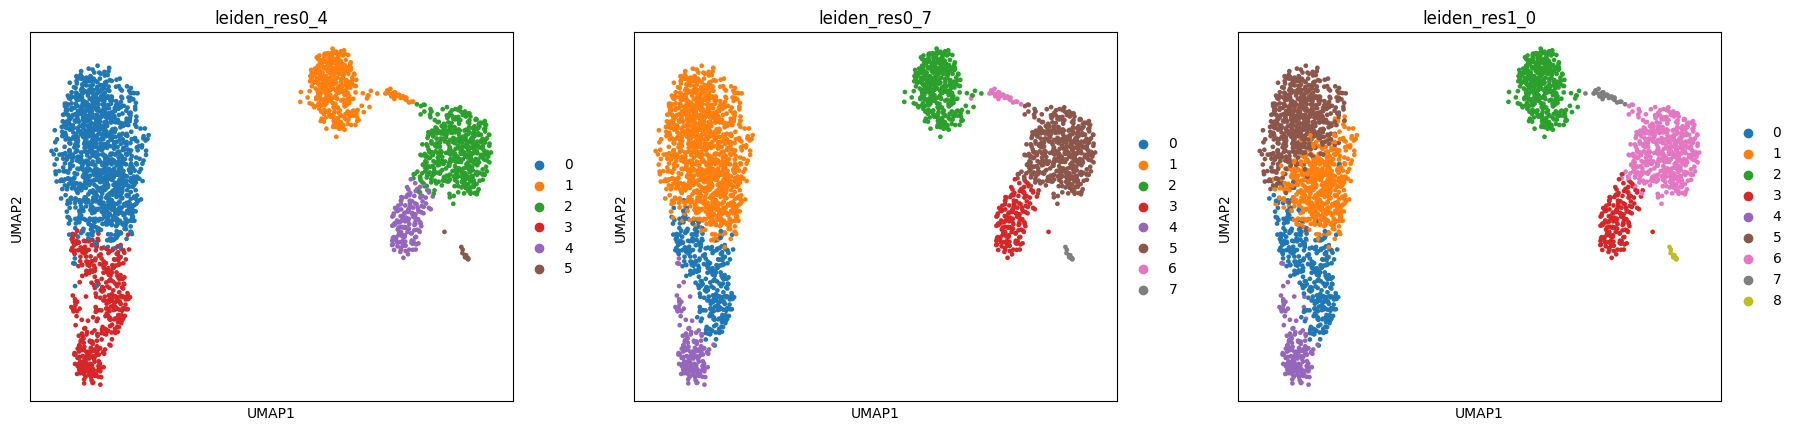

In [15]:
sc.tl.leiden(adata, key_added='leiden_res0_7', resolution=0.7, random_state=0,flavor='igraph',n_iterations=2,directed=False)
sc.tl.leiden(adata, key_added='leiden_res0_4', resolution=0.4, random_state=0,flavor='igraph',n_iterations=2,directed=False)
sc.tl.leiden(adata, key_added='leiden_res1_0', resolution=1,random_state=0, flavor='igraph',n_iterations=2,directed=False)
"""
# the scanpy tutorial runs the following bit of code to convert views to objects, but i've added different keys to view different resolutions.
# the key matching the tutorial parameters is 'leiden_res0_7'
adata.obs['leiden'] = adata.obs['leiden'].copy() # converting views to objects
adata.uns['leiden'] = adata.uns['leiden'].copy()
adata.obsm['X_umap'] = adata.obsm['X_umap'].copy()
"""
sc.pl.umap(adata, color = ['leiden_res0_4','leiden_res0_7','leiden_res1_0'])

## Saving clustered data

In [16]:
clustered_data = '../data/pbmc3k_clustered.h5ad'
adata.write(clustered_data, compression='gzip')
# verifying
if os.path.exists(clustered_data):
    print('clustered data saved successfully.')
else:
    print('nope.')

clustered data saved successfully.
